# Progetto di Cavallari Anna matr. 1099291 e Gobbo Chiara matr.1096072

## ANALISI SU DATASET AI JOB RECOMMENDATION
- Preprocessing
- Distribuzione delle variabili
- Clustering (K-Means e DBSCAN)
- Modelli di Machine Learning (Regressione lineare, Logistic regression, Random forest)

___
## 1. Importazione librerie

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, mean_squared_error, r2_score, ConfusionMatrixDisplay
from sklearn.cluster import KMeans, DBSCAN
from scipy.stats import chi2_contingency

print('Librerie caricate') 

Librerie caricate


___
## 2. Caricamento del dataset

In [41]:
file_path = "ds/job_recommendation_structured.csv"
df = pd.read_csv(file_path)
print(f"Dataset caricato: {df.shape[0]:,} righe × {df.shape[1]} colonne")

Dataset caricato: 50,000 righe × 7 colonne


___
## 3. Ispezione iniziale del dataset

Prime 5 righe e informazioni generali sulle colonne (tipo, valori non nulli)

In [42]:
print("Prime righe del dataset")
print(df.head())

print("\nInfo")
print(df.info())

Prime righe del dataset
                         Job Title                      Company  \
0              Early years teacher               Richardson Ltd   
1         Counselling psychologist  Ramos, Santiago and Stewart   
2        Radio broadcast assistant                 Franco Group   
3     Designer, exhibition/display                  Collins Inc   
4  Psychotherapist, dance movement                 Barker Group   

        Location Experience Level    Salary     Industry  \
0         Sydney     Senior Level   81800.0       EdTech   
1  San Francisco        Mid Level  105800.0  IT Services   
2       New York        Mid Level   56300.0       EdTech   
3         Berlin     Senior Level  135700.0   Healthcare   
4         Sydney      Entry Level   76900.0     Software   

                               Required Skills  
0      Pedagogy, Curriculum Design, E-learning  
1                              AWS, React, SQL  
2                E-learning, Curriculum Design  
3  Patient Care,

___
## 4. Controllo valori manccanti

Verifichiamo la presenza di missing values nel dataset

In [43]:
missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'percent': df.isnull().mean() * 100
}).query('count > 0').sort_values('percent', ascending=False)


if missing.empty:
    print('Nessun valore mancante')
else:
    print(f'{len(missing)} colonne con valori mancanti:')
    display(missing.style.bar(subset=['percent'], color='#d65f5f'))

df.isnull().sum()


Nessun valore mancante


Job Title           0
Company             0
Location            0
Experience Level    0
Salary              0
Industry            0
Required Skills     0
dtype: int64

___
## 5. Controllo righe duplicate

In [44]:
n_dup = df.duplicated().sum()
print(f'n duplicati: {n_dup} ({n_dup / len(df) * 100:.2f}%)')

n duplicati: 0 (0.00%)


___
## 6. Analisi delle variabili categoriali

Identifichiamo le colonne testuali e categoriali per valutare la cardinalità, cioè il numero di valori univoci

In [45]:
df.columns

Index(['Job Title', 'Company', 'Location', 'Experience Level', 'Salary',
       'Industry', 'Required Skills'],
      dtype='str')

In [46]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f'Colonne categoriche ({len(cat_cols)}): {cat_cols}')

Colonne categoriche (6): ['Job Title', 'Company', 'Location', 'Experience Level', 'Industry', 'Required Skills']


### Cardinalità

In [47]:
cardinality = df[cat_cols].nunique().sort_values(ascending=False)
print('Cardinalità colonne categoriche:')
display(cardinality.to_frame('n_unique'))

Cardinalità colonne categoriche:


,n_unique
Company,37022
Job Title,639
Required Skills,250
Industry,8
Location,7
Experience Level,3


Geestione esclusione ddelle colonne con tanti valori univoci e difficili da gestire

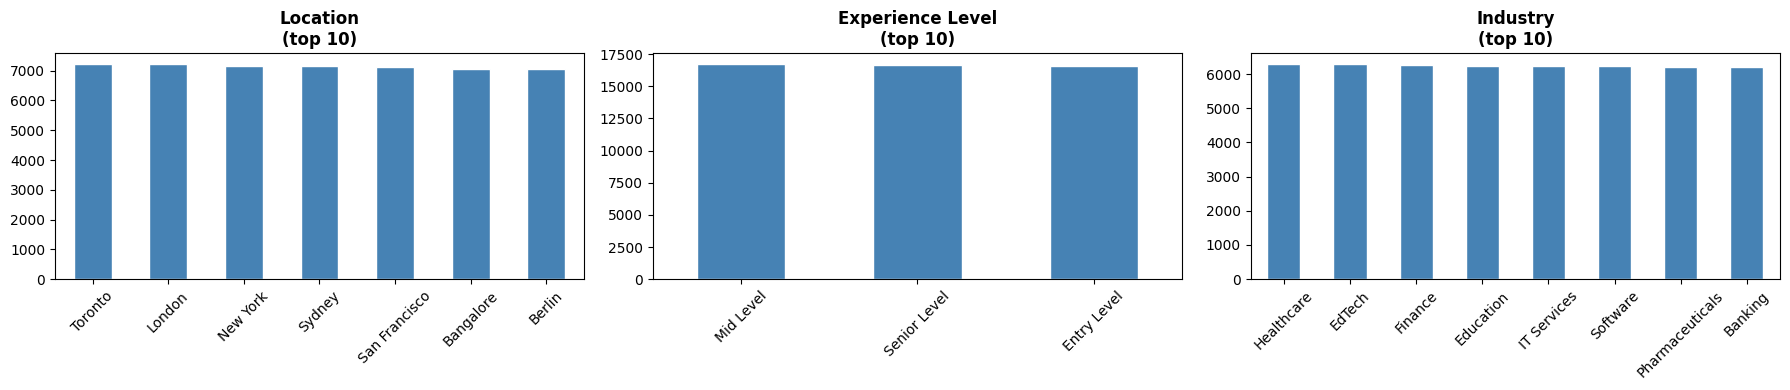

In [48]:
low_card = [c for c in cat_cols if df[c].nunique() <= 50]

if low_card:
    n = len(low_card)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]
    
    for ax, col in zip(axes, low_card):
        counts = df[col].value_counts().head(10)
        counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(f'{col}\n(top 10)', fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print('Tutte le colonne categoriche hanno più di 50 valori')

___
## 7. Analisi delle variabili numeriche

Il dataset contiene una sola variabile numerica continua: `Salary`.
Ne osserviamo la distribuzione tramite istogramma:

Colonne numeriche: ['Salary']


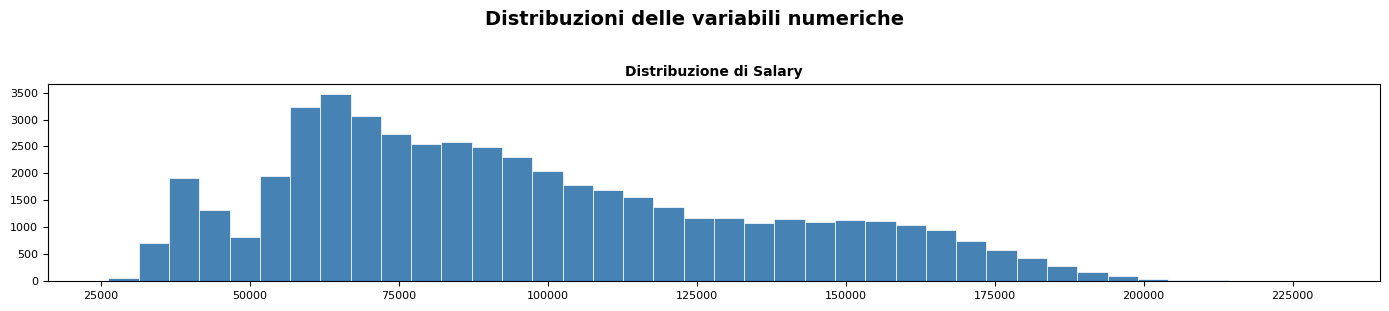

In [49]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print("Colonne numeriche:", num_cols)

n = len(num_cols) #colonne numeriche

fig, axes = plt.subplots(n, 1, figsize=(14, n * 3))
axes = np.array(axes).reshape(-1).flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'Distribuzione di {col}', fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)): # funziona solo se ci sono degli assi vuoti
    axes[j].set_visible(False)

fig.suptitle('Distribuzioni delle variabili numeriche', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

___
## 8. Box plot

Analisi della distribuzione del salario e di come varia questo in base alle altre variabili categoriali

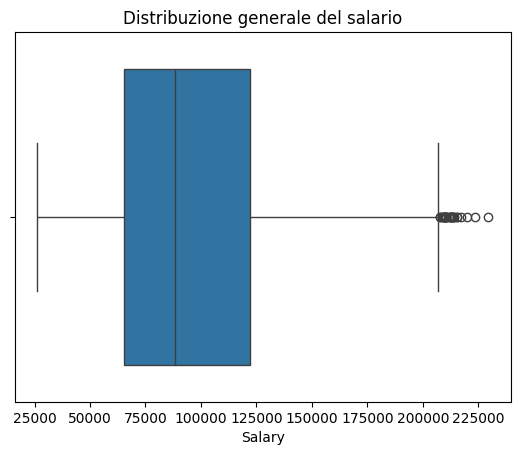

In [50]:
sns.boxplot(x=df['Salary'])
plt.title("Distribuzione generale del salario")
plt.show()

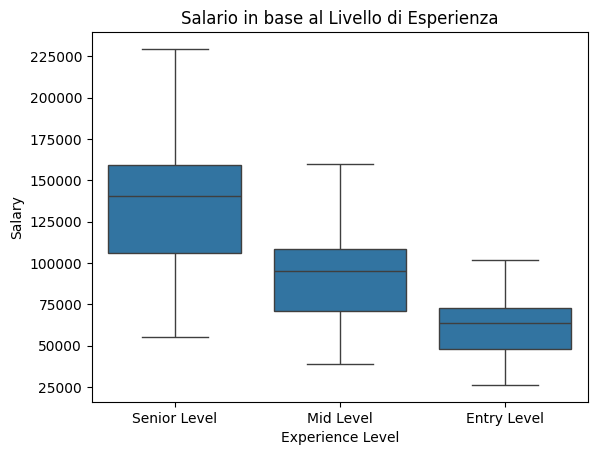

In [51]:
sns.boxplot(x='Experience Level', y='Salary', data=df)
plt.title("Salario in base al Livello di Esperienza")
plt.show()

Si osserva che il salario varia tra i diversi livelli di esperienza, ciò significa nel dataset esiste una relazione tra esperienza e salario

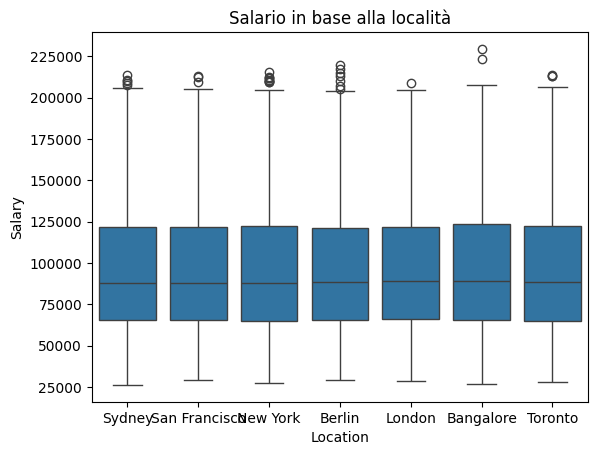

In [52]:
sns.boxplot(x='Location', y='Salary', data=df)
plt.title("Salario in base alla località")
plt.show()

In questo caso non ci son delle differenze rilevanti ma minime, ad esempio a New York il terzo quartile tocca un livello di salario più basso rispetto alle altre città, mentre London ha suo primo quartile che parte da un livello di salario base più alto. La mediana più alta si trova in Bangalore

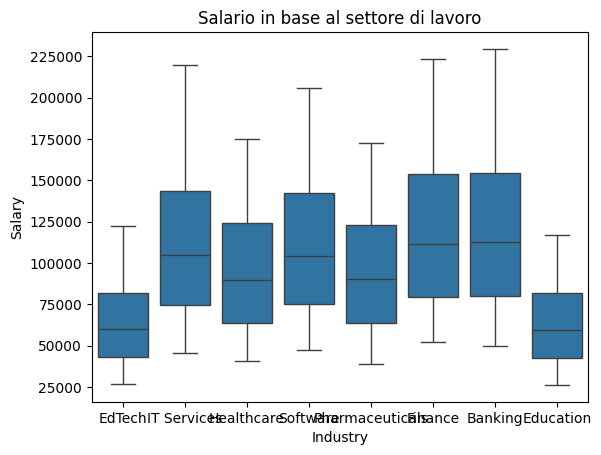

In [53]:
sns.boxplot(x='Industry', y='Salary', data=df)
plt.title("Salario in base al settore di lavoro")
plt.show()

i settori finanziari, come Banking e Finance, si distinguono per le mediane più elevate, segno di una maggiore remunerazione complessiva.
Un andamento simile, seppur leggermente più contenuto, si osserva nei settori tecnologici, come IT Services e Software, che mostrano salari medi elevati e una discreta variabilità. Questo riflette la crescente domanda di competenze digitali e il valore attribuito a profili tecnici avanzati nel mercato del lavoro contemporaneo.
i settori legati all’istruzione, come Education ed EdTech, presentano livelli salariali mediamente più bassi e una distribuzione più compatta.
 I settori sanitario e farmaceutico si collocano in una posizione intermedia, con salari medi moderati e una variabilità contenuta, indicando una certa stabilità ma anche minori opportunità di elevata crescita retributiva rispetto ad altri ambiti.

___
## 9. Analisi delle Correlazioni

### 9.1 Chi-Quadro delle variabili categoriali

Verificihiamo con il Chi-Quadro se esiste una relazione statistica significativa tra `Industry` e `Experience Level`
Ricordare che l'ipotesi nulla va rifiutaata se il p-value è minore di 0,05, allora quindi c'è una relazione significativa

Risultati tra 'Industry' e 'Experience Level':
P-value: 0.2488 Chi2: 17.1408 Gradi di libertà: 14
Non c'è una relazione statistica significativa


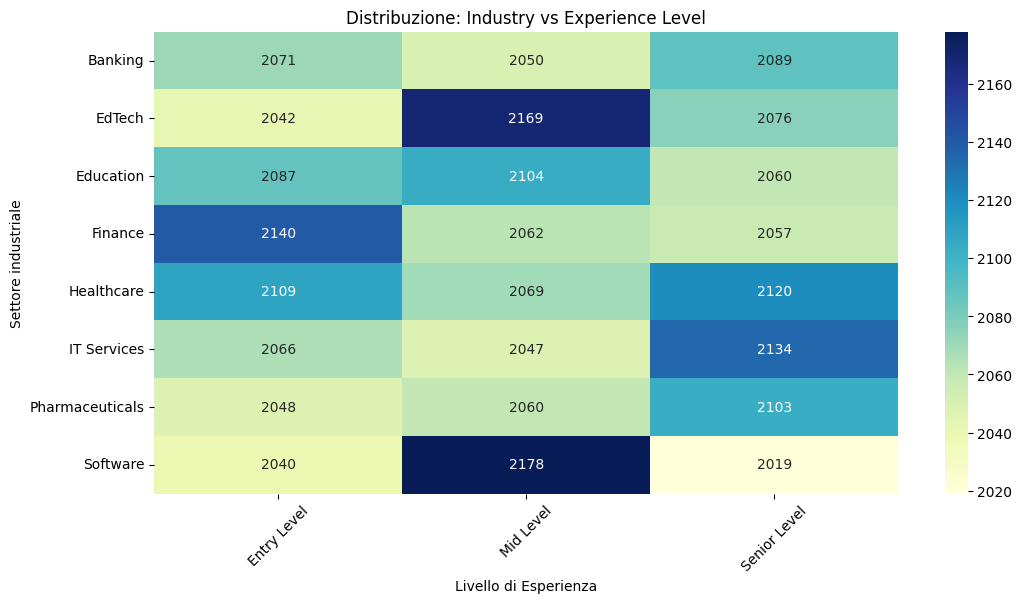

In [54]:
cat_cols_corr = ['Industry', 'Experience Level'] 

# n osservazioni per combinazone
contingency_table = pd.crosstab(df[cat_cols_corr[0]], df[cat_cols_corr[1]])

chi2, p, dof, ex = chi2_contingency(contingency_table)

print(f"Risultati tra '{cat_cols_corr[0]}' e '{cat_cols_corr[1]}':")
print(f"P-value: {p:.4f} Chi2: {chi2:.4f} Gradi di libertà: {dof}")

if p < 0.05:
    print("Esiste una relazione significativa tra ruolo e livello di esperienza")
else:
    print("Non c'è una relazione statistica significativa")

plt.figure(figsize=(12, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Distribuzione: {cat_cols_corr[0]} vs {cat_cols_corr[1]}')
plt.xlabel('Livello di Esperienza')
plt.ylabel('Settore industriale')
plt.xticks(rotation=45)
plt.show()

L’analisi condotta tramite il test del Chi-quadro evidenzia che non esiste una relazione statisticamente significativa tra il settore lavorativo (Industry) e il livello di esperienza (Experience Level). In particolare, il valore del p-value risulta superiore alla soglia di significatività convenzionale (0,05), motivo per cui non è possibile rifiutare l’ipotesi nulla di indipendenza tra le due variabili. Ciò implica che la distribuzione dei livelli di esperienza appare sostanzialmente uniforme tra i diversi settori considerati. Questa evidenza è coerente anche con la rappresentazione tramite heatmap, nella quale le frequenze osservate risultano simili tra le varie combinazioni settore–esperienza, senza emergere pattern evidenti o concentrazioni anomale. Nel complesso, i risultati suggeriscono che, all’interno del dataset analizzato, il settore di appartenenza non costituisce un fattore determinante nel differenziare i livelli di esperienza degli individui, indicando quindi una sostanziale indipendenza tra le due dimensioni analizzate.

### 9.2 Distribuzione del salario per livello di esperienza

<Axes: xlabel='Salary', ylabel='Count'>

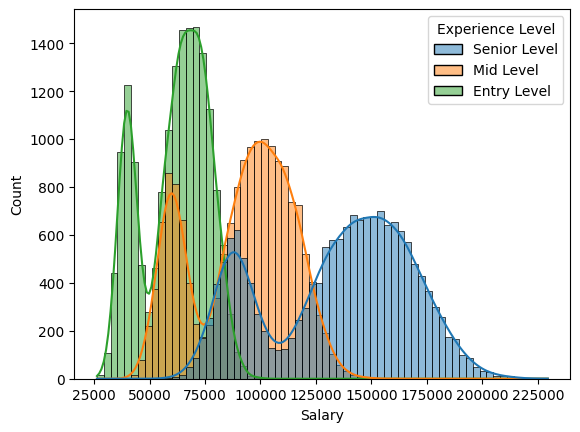

In [55]:
sns.histplot(df, x='Salary', hue='Experience Level', kde=True)

Il grafico mostra la distribuzione dei salari in funzione del livello di esperienza, evidenziando differenze nette tra le tre categorie considerate (Entry, Mid e Senior Level). In particolare, emerge un chiaro gradiente crescente dei salari all’aumentare dell’esperienza: i lavoratori Entry Level si concentrano prevalentemente nelle fasce più basse (circa 40.000–80.000), i Mid Level occupano una posizione intermedia (circa 70.000–120.000), mentre i Senior Level presentano una distribuzione spostata verso valori significativamente più elevati (oltre 120.000, con picchi intorno ai 150.000).

___
## 10. Analisi delle skills più richieste

La colonna `Required Skills` contiene più skill separate da virgola, bisogn normalizzare qquesta cella

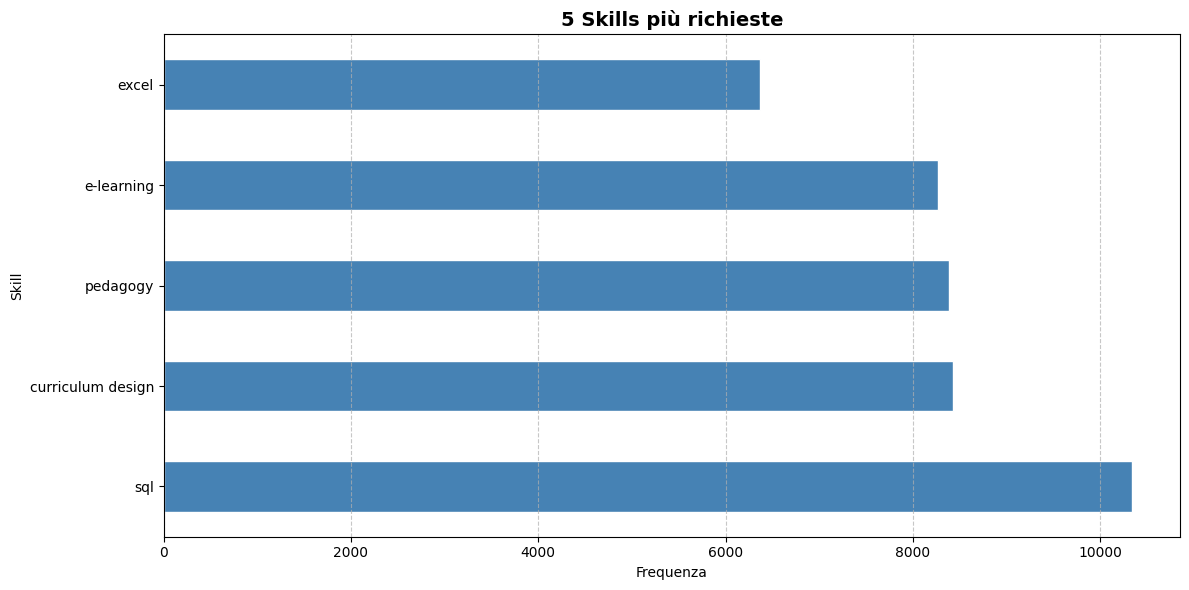

In [56]:
skills_split = df['Required Skills'].str.split(',', expand=True) # expand=True crea un DataFrame con una colonna per ogni skill

# Trasformiamo tutto il DataFrame in una singola colonna (Series)
# stack() impila tutte le colonne una sotto l'altra
all_skills = skills_split.stack()

all_skills = all_skills.str.strip().str.lower() # no spazi bianchi e tutto minuscolo

top_5_skills = all_skills.value_counts().head(5)

plt.figure(figsize=(12, 6))
top_5_skills.plot(kind='barh', color='steelblue', edgecolor='white')

plt.title('5 Skills più richieste', fontsize=14, fontweight='bold')
plt.xlabel('Frequenza')
plt.ylabel('Skill')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


le competenze più richieste nel datasetsono SQL e curriculum design come le skill più frequenti, seguite da pedagogia, e-learning e excel

___
## 11. Media del salario per livello di esperienza

In [57]:
mean_salary = df.groupby('Experience Level')['Salary'].mean().sort_values(ascending=False)
print("Media salario per livello di esperienza")
print(mean_salary.to_frame('Salary medio').round(2))

Media salario per livello di esperienza
                  Salary medio
Experience Level              
Senior Level         134709.19
Mid Level             91536.24
Entry Level           61304.07


___
## 12. Preprocessing per il Clustering

Per poter applicare algoritmi di clustering (LAVORANO CON DATI NUMERICI) dobbiamo:
1. Rendere le variabili categoriche numeriche
2. Standardizzare TUTTE le feature con StandardScaler (media 0, deviazione standard 1)

Usiamo le variabili `Location`, `Experience Level`, `Industry` e `Salary`.

In [61]:
cols_to_encode = ['Location', 'Experience Level', 'Industry']

df_numeric = pd.get_dummies(
    df[['Location', 'Experience Level', 'Industry', 'Salary']],
    columns=cols_to_encode
).astype(float)

print(f"Feature dopo One-Hot Encoding: {df_numeric.shape[1]} colonne")
print(df_numeric.columns.tolist())

Feature dopo One-Hot Encoding: 19 colonne
['Salary', 'Location_Bangalore', 'Location_Berlin', 'Location_London', 'Location_New York', 'Location_San Francisco', 'Location_Sydney', 'Location_Toronto', 'Experience Level_Entry Level', 'Experience Level_Mid Level', 'Experience Level_Senior Level', 'Industry_Banking', 'Industry_EdTech', 'Industry_Education', 'Industry_Finance', 'Industry_Healthcare', 'Industry_IT Services', 'Industry_Pharmaceuticals', 'Industry_Software']


Mettiamo lo scaler perchè la variabile Salary ha una scalatura diversa da quella delle variabili dummy create sopra e i modelli ci danno più importanza

In [62]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print(f"{X_scaled.shape}")

(50000, 19)


___
## 13. Clustering

### 13.1 Metodo del gomito
Prima di applicare K-Means, usiamo il metodo del gomito per determinare il numero ottimale di cluster `k`.
L'inerzia è la somma delle distanze al quadrato di ogni punto dal suo centroide: al crescere di `k` l'inerzia decresce, ma oltre un certo punto il guadagno diventa trascurabile

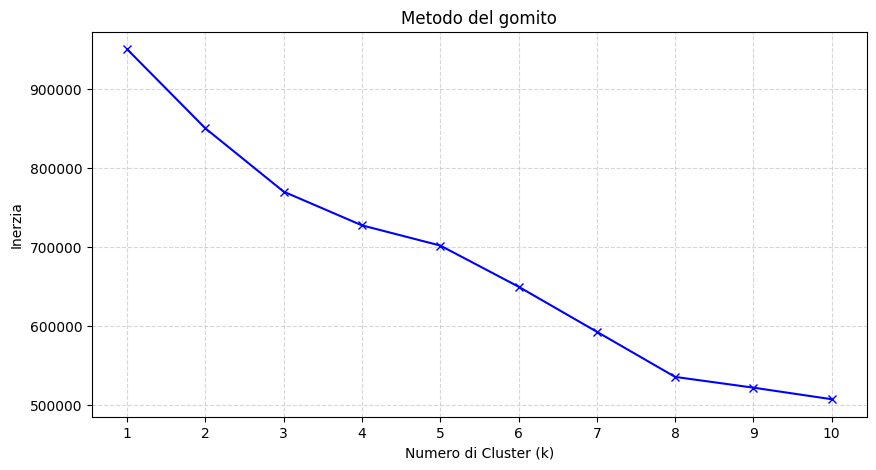

In [63]:
inertia = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Numero di Cluster (k)')
plt.ylabel('Inerzia')
plt.title("Metodo del gomito")
plt.xticks(K)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Non abbiamo un bel grafico, c'è però una variazione di pendenza intorno a k=3. 
Abbiamo scelto k=3 perchè il dataset è strutturaato in 3 sezioni più importanti, i quali sono i 3 livelli di esperienza (Entry, Mid, Senior Level).

## 13.2 K-Means

In [64]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled) # nuova colonna cluster che assegna il cluster di riferimento

print("Distribuzione dei campioni nei cluster:")
print(df['Cluster'].value_counts().sort_index())

Distribuzione dei campioni nei cluster:
Cluster
0    16658
1    16739
2    16603
Name: count, dtype: int64


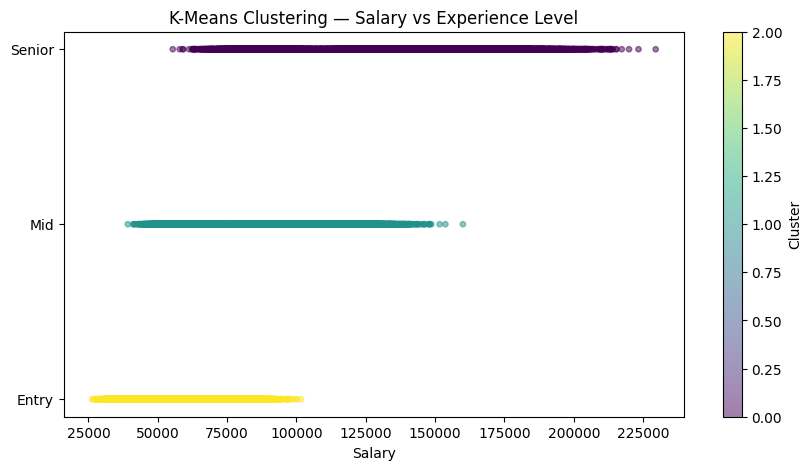

In [65]:
exp_map = {'Entry Level': 0, 'Mid Level': 1, 'Senior Level': 2}
df['exp_num'] = df['Experience Level'].map(exp_map)

plt.figure(figsize=(10, 5))
plt.scatter(df['Salary'], df['exp_num'], c=df['Cluster'], cmap='viridis', s=15, alpha=0.5)
plt.yticks([0, 1, 2], ['Entry', 'Mid', 'Senior'])
plt.xlabel('Salary')
plt.title('K-Means Clustering — Salary vs Experience Level')
plt.colorbar(label='Cluster')
plt.show()

i cluster identificati coincidono in larga misura con i tre livelli di esperienza (Entry, Mid e Senior), suggerendo che il salario costituisce una variabile altamente discriminante. In particolare, i lavoratori Entry Level si concentrano nel cluster con salari più bassi (circa 30.000–100.000), i Mid Level occupano una fascia intermedia (circa 50.000–150.000), mentre i Senior Level si collocano nel cluster con salari più elevati (oltre 60.000 fino a oltre 200.000).

## 13.3 DBSCAN

DBSCAN (Density-Based Spatial Clustering) identifica cluster in base alla densità dei punti nello spazio.
A differenza di K-Means, non richiede di specificare il numero di cluster in anticipo e può rilevare punti anomali (rumore, etichettati con -1).

- `eps`: raggio del vicinato di un punto
- `min_samples`: numero minimo di punti per formare un cluster denso

In [66]:
dbscan = DBSCAN(eps=2.0, min_samples=10)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(df['Cluster_DBSCAN'])) - (1 if -1 in df['Cluster_DBSCAN'].values else 0)
n_noise = (df['Cluster_DBSCAN'] == -1).sum()

print(f"DBSCAN ha individuato {n_clusters_dbscan} cluster.")
print(f"Punti classificati come rumore (outlier): {n_noise} ({n_noise/len(df)*100:.2f}%)")
print("\nDistribuzione:")
print(df['Cluster_DBSCAN'].value_counts().sort_index())

DBSCAN ha individuato 168 cluster.
Punti classificati come rumore (outlier): 0 (0.00%)

Distribuzione:
Cluster_DBSCAN
0      309
1      304
2      330
3      288
4      307
      ... 
163    286
164    328
165    316
166    304
167    302
Name: count, Length: 168, dtype: int64


il risultato evidenzia una bassa capacità di sintesi del modello in questa configurazione, rendendo difficile un’interpretazione significativa dei cluster individuati. A differenza del K-Means, che ha prodotto una segmentazione coerente con i livelli di esperienza, DBSCAN in questo caso non riesce a individuare strutture aggregative rilevanti.

## 14. Visualizzazione dei cluster
### 14.1 Boxplot Salario per cluster del K-Means
Confrontiamo la distribuzione del salario all'interno di ogni cluster

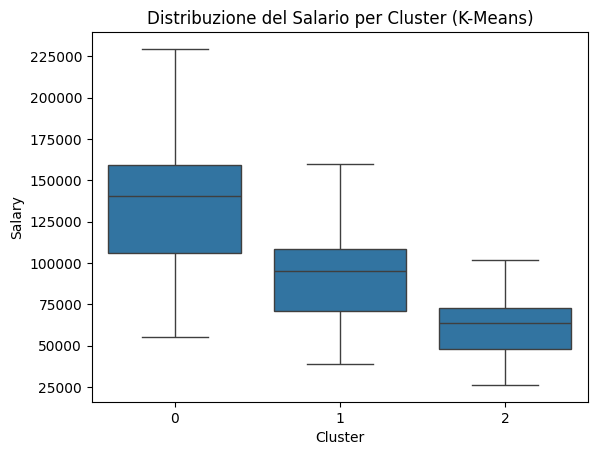

Media salario per cluster:
Cluster
2     61304.07
1     91536.24
0    134709.19
Name: Salary, dtype: float64


In [67]:
sns.boxplot(x='Cluster', y='Salary', data=df)
plt.title('Distribuzione del Salario per Cluster (K-Means)')
plt.xlabel('Cluster')
plt.ylabel('Salary')
plt.show()

print("Media salario per cluster:")
print(df.groupby('Cluster')['Salary'].mean().sort_values().round(2))

emerge una distinzione netta tra i tre cluster: il cluster 0 presenta i salari mediamente più elevati (circa 134.700), con una distribuzione ampia e una maggiore variabilità, segno della presenza di profili ad alta retribuzione e maggiore eterogeneità interna. Il cluster 1 si colloca in una posizione intermedia (circa 91.500), rappresentando una fascia salariale media con dispersione moderata. Infine, il cluster 2 raccoglie i salari più bassi (circa 61.300), con una distribuzione più compatta, indicativa di minore variabilità.

L’andamento crescente delle mediane tra i cluster suggerisce una chiara stratificazione retributiva, coerente con quanto osservato nelle analisi precedenti sul livello di esperienza.

### 14.2 Confronto K-Means e DBSCAN

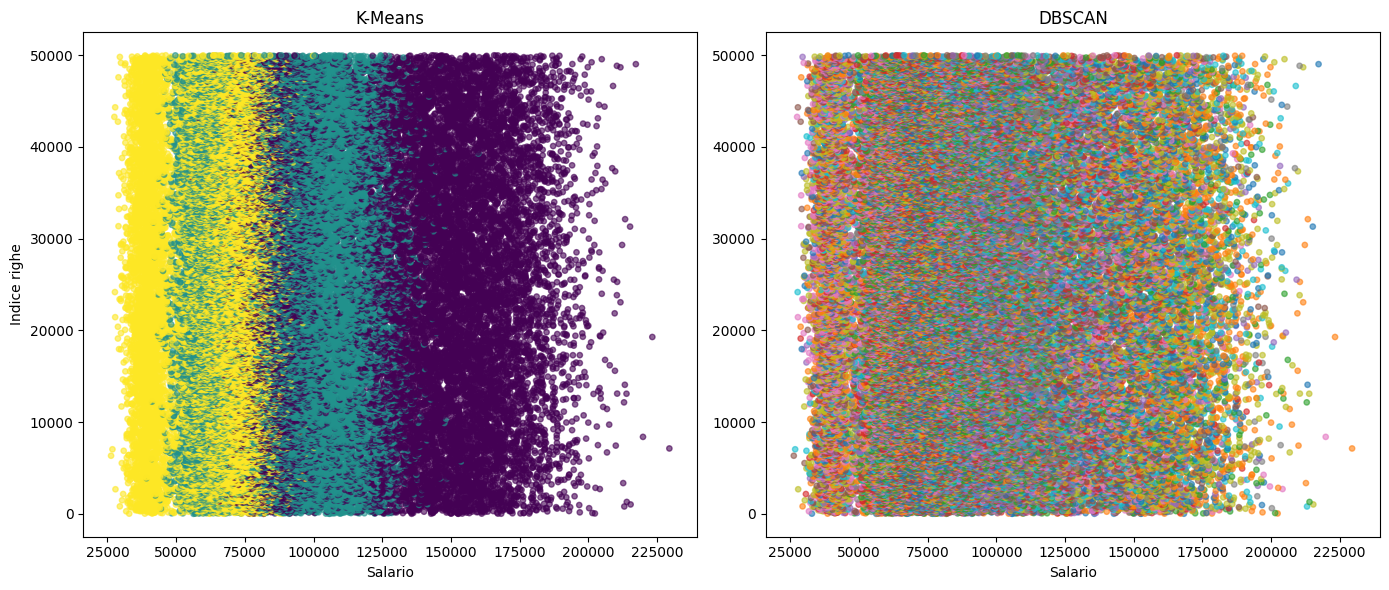

DBSCAN ha individuato 168 cluster.


In [68]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(df['Salary'], np.arange(len(df)), c=df['Cluster'], cmap='viridis', s=15, alpha=0.6)
plt.title('K-Means')
plt.xlabel('Salario')
plt.ylabel('Indice righe')

plt.subplot(1, 2, 2)
plt.scatter(df['Salary'], np.arange(len(df)), c=df['Cluster_DBSCAN'], cmap='tab10', s=15, alpha=0.6)
plt.title('DBSCAN')
plt.xlabel('Salario')

plt.tight_layout()
plt.show()

n_clusters = len(set(df['Cluster_DBSCAN'])) - (1 if -1 in df['Cluster_DBSCAN'] else 0)
print(f"DBSCAN ha individuato {n_clusters} cluster.")

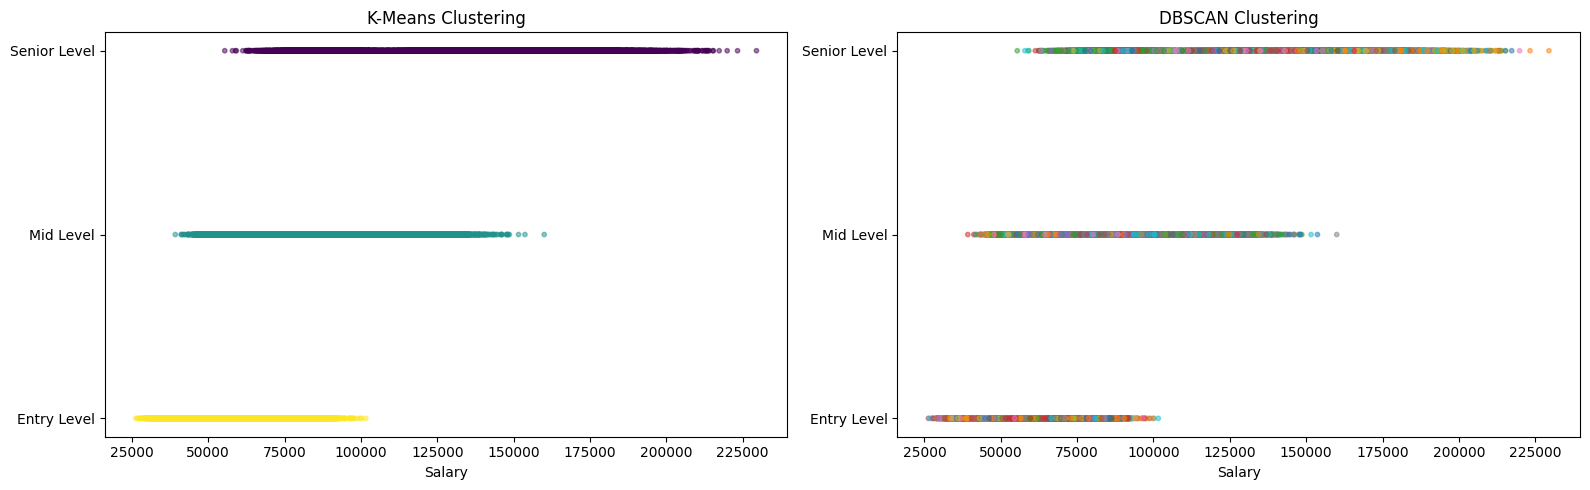

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(df['Salary'], df['exp_num'], c=df['Cluster'], cmap='viridis', s=10, alpha=0.5)
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(['Entry Level', 'Mid Level', 'Senior Level'])
axes[0].set_xlabel('Salary')
axes[0].set_title('K-Means Clustering')

axes[1].scatter(df['Salary'], df['exp_num'], c=df['Cluster_DBSCAN'], cmap='tab10', s=10, alpha=0.5)
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['Entry Level', 'Mid Level', 'Senior Level'])
axes[1].set_xlabel('Salary')
axes[1].set_title('DBSCAN Clustering')

plt.tight_layout()
plt.show()

Il confronto tra K-Means e DBSCAN mette in evidenza differenze molto marcate nella capacità dei due algoritmi di individuare strutture significative nei dati.

Nel caso di K-Means, la segmentazione appare chiara e interpretabile: i punti sono suddivisi in pochi cluster ben distinti lungo l’asse del salario, formando bande verticali ordinate. Quando si considera anche il livello di esperienza, emerge una forte coerenza tra cluster e categorie (Entry, Mid, Senior), confermando che l’algoritmo è riuscito a catturare una struttura reale dei dati. I cluster risultano quindi compatti, separati e facilmente leggibili, rendendo K-Means particolarmente efficace in questo contesto.

Al contrario, DBSCAN restituisce una rappresentazione molto frammentata: i punti appaiono distribuiti in numerosi cluster di piccole dimensioni, senza una chiara separazione visiva. I colori risultano mescolati e privi di pattern riconoscibili, sia nella distribuzione generale sia rispetto ai livelli di esperienza. Questo comportamento è coerente con quanto osservato nei risultati numerici, dove l’algoritmo ha individuato un numero molto elevato di cluster, perdendo capacità di sintesi.

Nel complesso, il confronto evidenzia come K-Means sia più adatto a questo dataset, in quanto riesce a individuare gruppi omogenei e interpretabili, fortemente legati alla variabile salario e al livello di esperienza. DBSCAN, invece, nella configurazione adottata, non riesce a cogliere una struttura significativa, producendo una segmentazione eccessivamente granulare e poco utile ai fini interpretativi.

___
## 15. Modelli di machine learning

Usiamo i cluster che sono stati trovati dal K-Means e li mettiamo come variabile taget, quindi con queste variabili andiamo ad usare dei modelli di classificazione supervisionata addestrati sul target. 
Dobbiamo andare a controllare se le feature del nostro dtaframe ci consentono di predire dei cluster validi

### 15.1 Divisione del dataset in train set e test set
80% per addestramento e 20% per le test. Stratify = y permette che la proporzione dei cluster sia la stessa per entrambi i set di dati

In [70]:
y = df['Cluster'] # target

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} campioni")
print(f"Test:  {X_test.shape[0]:,} campioni")

Train: 40,000 campioni
Test:  10,000 campioni


### 15.2 Logistic regression

Modello lineare, si separano i cluster in base alle feature

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00      3332
   Cluster 1       1.00      1.00      1.00      3348
   Cluster 2       1.00      1.00      1.00      3320

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



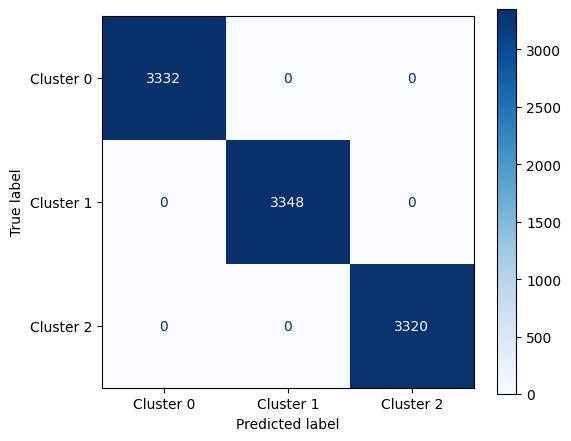

In [71]:
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr, target_names=['Cluster 0', 'Cluster 1', 'Cluster 2']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
    cmap='Blues', ax=ax
)
plt.show()

L’applicazione della regressione logistica per la classificazione dei cluster restituisce risultati apparentemente perfetti, con accuracy pari a 1.00 e valori di precision, recall e F1-score tutti uguali a 1.00 per ciascun cluster. Anche la matrice di confusione conferma questa performance: tutte le osservazioni sono correttamente classificate lungo la diagonale principale, senza alcun errore.

### 15.3 Random forest

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00      3332
   Cluster 1       1.00      1.00      1.00      3348
   Cluster 2       1.00      1.00      1.00      3320

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



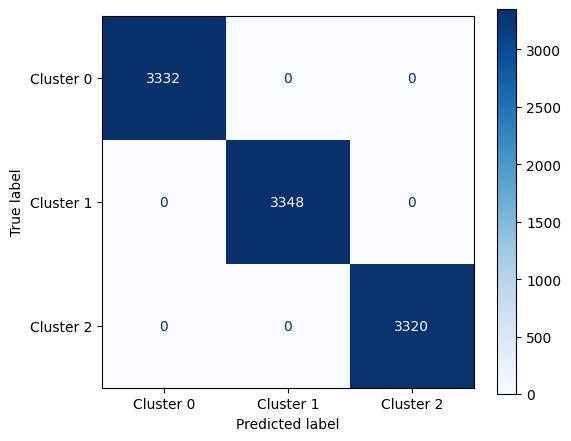

In [72]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=['Cluster 0', 'Cluster 1', 'Cluster 2']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
    cmap='Blues', ax=ax
)
plt.show()

Anche il modello di Random Forest restituisce performance apparentemente perfette, con accuracy pari a 1.00 e valori di precision, recall e F1-score tutti pari a 1.00 per ciascun cluster. La matrice di confusione conferma ulteriormente questo risultato, mostrando una classificazione completamente corretta senza errori, con tutti i valori concentrati sulla diagonale principale.

### 15.4 Regressione lineare

Stimiamo il salariio in base a location, experience level e industry

In [73]:
cols_to_encode_lr = ['Location', 'Experience Level', 'Industry']

df_lr = pd.get_dummies(
    df[['Location', 'Experience Level', 'Industry']],
    columns=cols_to_encode_lr
).astype(float)

X_lr = df_lr.values
y_lr = df['Salary'].values

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train_lr, y_train_lr)
y_pred_lin = lin_reg.predict(X_test_lr)

r2   = r2_score(y_test_lr, y_pred_lin)
rmse = np.sqrt(mean_squared_error(y_test_lr, y_pred_lin))

print(f"R quadrato   : {r2:.4f}")
print(f"RMSE : {rmse:,.2f} $")


R quadrato   : 0.9017
RMSE : 12,106.36 $


Il modello ottiene un R quadrato di 0,90, circa il 90% della variazione del salario è stato spiegato dalle variabili che abbiamo scelto. L'errore medio è di circa 12.000, quindi le variabili categoriche disponibili sono sufficientemente informative per stimare la fascia salariale di un lavoratore.

### Confronto tra i due modelli, logistic regression e random forest

Acc Logistic Regression : 1.0000 (100.00%)
Acc Random Forest       : 1.0000 (100.00%)


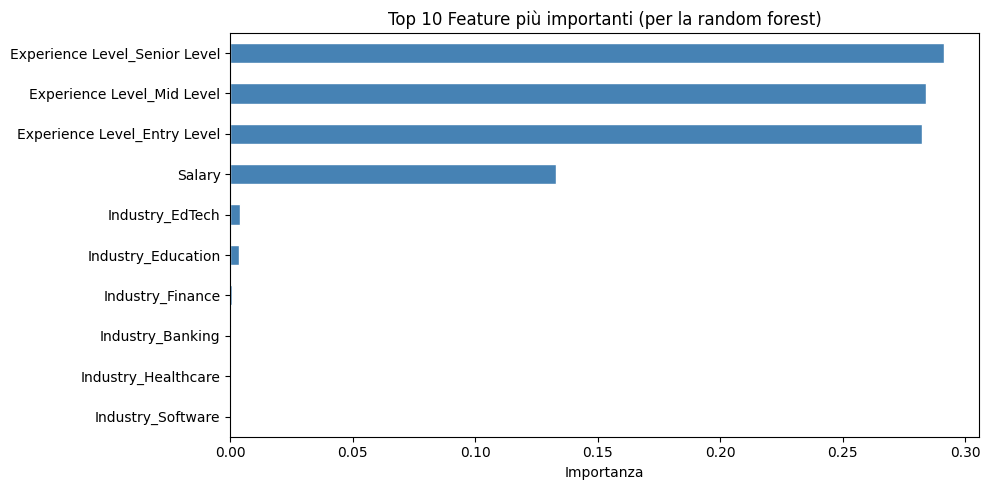

In [74]:
# Accuracy a confronto
acc_lr = lr.score(X_test, y_test)
acc_rf = rf.score(X_test, y_test)

print(f"Acc Logistic Regression : {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"Acc Random Forest       : {acc_rf:.4f} ({acc_rf*100:.2f}%)")

# Feature importance da Random Forest
importances = pd.Series(rf.feature_importances_, index=df_numeric.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_features.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 Feature più importanti (per la random forest)')
plt.xlabel('Importanza')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [75]:
y = df['Cluster']          # target = cluster trovato
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Logistic Regression
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
print(classification_report(y_test, lr.predict(X_test)))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print(classification_report(y_test, rf.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3316
           1       1.00      1.00      1.00      3332
           2       1.00      1.00      1.00      3352

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3316
           1       1.00      1.00      1.00      3332
           2       1.00      1.00      1.00      3352

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



Il confronto tra regressione logistica e Random Forest evidenzia risultati perfettamente sovrapponibili, con entrambi i modelli che raggiungono un’accuracy pari al 100% e valori di precision, recall e F1-score uguali a 1.00 per tutte le classi. Questo indica che i cluster individuati sono completamente separabili nello spazio delle feature considerate, e che sia un modello lineare sia uno non lineare sono in grado di classificarli senza alcun errore.

L’analisi della feature importance della Random Forest fornisce però un elemento interpretativo fondamentale: le variabili più rilevanti risultano essere i livelli di esperienza (Entry, Mid, Senior), seguiti dal salario, mentre le variabili relative al settore (Industry) hanno un impatto trascurabile. Questo suggerisce che la segmentazione dei cluster è guidata principalmente da esperienza e retribuzione, mentre il settore non contribuisce in modo significativo alla distinzione tra i gruppi.

Nel complesso, il confronto mostra che:

- non vi sono differenze prestazionali tra i due modelli, data la forte separabilità dei dati;
- la regressione logistica è sufficiente a catturare la struttura (quindi il problema è linearmente separabile);
- la Random Forest conferma tale struttura e permette di interpretare il peso delle variabili.

___
## conclusioni finali:


Nel complesso, i risultati ottenuti nel progetto evidenziano una struttura dei dati chiara, coerente e fortemente interpretabile, in cui il salario e il livello di esperienza emergono come variabili centrali nell’organizzazione e nella segmentazione delle osservazioni.

Le analisi esplorative hanno mostrato una relazione positiva e ben definita tra esperienza e retribuzione, con una progressione salariale evidente passando da livelli Entry a Mid fino a Senior. Al contrario, il settore lavorativo (Industry) non sembra influenzare in modo significativo la distribuzione dell’esperienza, come confermato dal test del Chi-quadro, suggerendo una sostanziale indipendenza tra queste due dimensioni.

Dal punto di vista del clustering, il modello K-Means si è dimostrato particolarmente efficace, individuando tre gruppi distinti e coerenti con i livelli di esperienza, caratterizzati da una chiara stratificazione salariale. Al contrario, DBSCAN non ha prodotto risultati interpretabili nella configurazione adottata, generando un numero eccessivo di cluster e perdendo capacità di sintesi, evidenziando così l’importanza della scelta dei parametri e dell’adeguatezza dell’algoritmo rispetto alla struttura dei dati.

Le fasi successive di modellazione hanno ulteriormente confermato la struttura dei dati. Sia la regressione logistica sia la Random Forest hanno raggiunto performance perfette (accuracy pari a 1.00), indicando che i cluster sono perfettamente separabili nello spazio delle feature.